##### AI TECH - Akademia Innowacyjnych Zastosowań Technologii Cyfrowych. Programu Operacyjnego Polska Cyfrowa na lata 2014-2020
<hr>

<br>
<br>
<br>
<br>
<br>
<br>
<br>
<center>
    <h1 style = "font-size:48px; font-weight:normal"><b>AI</b>-TECH</h1>
    <br>
<br>
<br>
<br>
    <h1 style = "font-size:24px; font-weight:normal">Przykład 6 DO LABORATORIUM 1</h1>
    <h1 style = "font-size:24px">z UCZENIA MASZYNOWEGO</h1>
    <h1 style = "font-size:24px">Regresja liniowa i logistyczna</h1>
    <h1 style = "font-size:24px">Tomasz Neumann</h1>
    <h3 style = "font-size:21px">Regresja logistyczna - wykorzystanie danych z MNIST i tensorflow</h3>
</center>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
<br>
    </body>
    </html>

![stopka.svg](stopka.svg)

<center>
Projekt współfinansowany ze środków Unii Europejskiej w ramach Europejskiego Funduszu Rozwoju Regionalnego 
Program Operacyjny Polska Cyfrowa na lata 2014-2020,
Oś Priorytetowa nr 3 "Cyfrowe kompetencje społeczeństwa" Działanie  nr 3.2 "Innowacyjne rozwiązania na rzecz aktywizacji cyfrowej" 
Tytuł projektu:  „Akademia Innowacyjnych Zastosowań Technologii Cyfrowych (AI Tech)”
    </center>

<hr>

# 1. Przykład 6

W tym przykładzie zaprezentowane zostanie działanie regresji logistycznej na zbiorze danych MNIST, który zawiera 70 tysięcy obrazków w odcieniach szarości o rozdzielczości 28x28 pikseli, który został zebrany przez Yann’a Lecun (http://yann.lecun.com/exdb/mnist/). Obrazki te zawierają zeskanowane zapisy cyfr: 0-9 co daje to do dyspozycji 10 klas.
Zbiór ten można wczytać na wiele różnych sposobów do projektu, ale żeby uniknąć w tym momencie pewnego preprocessingu skorzystamy z możliwości biblioteki tensorflow.

Do celów aktualnego ćwiczenia przemodelujemy opis klas do problamu binarnego w którym cyfry od 0 do 8 będą stanowić klasę 0, zaś klasę 1 będą stanowić cyfry 9.


In [2]:
# Import podstawowych bibliotek
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
# Brak kompatybilnej wersji TF/Keras - pobieramy przez numpy
# import keras
# import tensorflow as tf
from sklearn.linear_model import LogisticRegression
from io import StringIO
import requests
from random import randint
# print(tf.__version__)
# print('keras:',keras.__version__)

W takim rozwiązaniu, zbiór wejściowy jest wczytywany od razu z podziałem na zbiór treningowy (60000) oraz testowy (10000). Zbiór testowy zostanie wykorzystany później do oceny treningu i wyznaczenia miar błędów.

In [3]:
import urllib.request
import os

if not os.path.exists('mnist.npz'):
    urllib.request.urlretrieve('https://storage.googleapis.com/tensorflow/tf-keras-datasets/mnist.npz', 'mnist.npz')

with np.load('mnist.npz', allow_pickle=True) as f:
    X_train, y_train = f['x_train'], f['y_train']
    X_test, y_test = f['x_test'], f['y_test']

#oryginalnie: (X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data(path='mnist.npz')

print("Training set size: ", X_train.shape)
print("Test set size: ", X_test.shape)

Training set size:  (60000, 28, 28)
Test set size:  (10000, 28, 28)


Do celów aktualnego ćwiczenia przemodelujemy opis klas, tak aby uzyskać problem binarny, w którym cyfry od 0 do 8 będą stanowić klasę 0, zaś klasę 1 będzie stanowić cyfry 9.

In [4]:
y_train_binary = np.where(y_train < 9, 0.0, 1.0).reshape(y_train.shape[0], 1)
y_train_binary = y_train_binary.astype('float32')

Dane wejściowe potraktujemy jako zbiór cech, stąd "spłaszczamy" reprezentację 2D do reprezentacji 1D (28*28 -> 784).
Taka spłaszczona reprezentacja obrazka przemnożona przez ilość obrazków występujących w rozważanym zbiorze daje nam wektor, który jest łatwiejszy do przetwarzania przez algorytmy uczenia maszynowego. Wartości te zostają również znormalizowane do przedziału [0,1].

In [5]:
#przygotowanie danych treningowych jako wektor znormalizowany
X_train_flat = X_train.reshape((X_train.shape[0], X_train.shape[1]*X_train.shape[2]))
X_train_flat = X_train_flat.astype('float32')/255.0
print("Input dataset shape: ", X_train_flat.shape)

#przygotowanie danych testowych jako wektor znormalizowany
y_test_binary = np.where(y_test < 9, 0.0, 1.0).reshape(y_test.shape[0], 1)
y_test_binary = y_test_binary.astype('float32').flatten()
X_test_flat = X_test.reshape((X_test.shape[0], X_test.shape[1]*X_test.shape[2]))
X_test_flat = X_test_flat.astype('float32')/255.0
print("Test dataset shape: ", X_test_flat.shape)

Input dataset shape:  (60000, 784)
Test dataset shape:  (10000, 784)


Przykładowy obraz z bazy danych, jego oryginalna etykieta oraz aktualna przynależność do klasy zostały przedstawione w poniższej sekcji.

True orginal label : 8
True binary label : [0.]


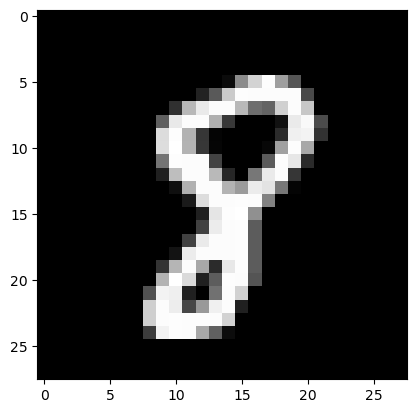

In [6]:
example = randint(0, 100)
plt.imshow(X_train[example], cmap="gray")
print("True orginal label :", y_train[example])
print("True binary label :", y_train_binary[example])

W tym kroku dopasowujemy model regresji logistycznej do "spłaszczonych" danych wejściowych oraz zaprezentowany zostanie wynik predykcji dla zbioru danych testowych

In [7]:
model = LogisticRegression(solver='newton-cg',random_state=0).fit(X_train_flat, y_train_binary.flatten())

print("Wynik ewaluacji wytrenowanego modelu: ",model.score(X_test_flat, y_test_binary.flatten()))

Wynik ewaluacji wytrenowanego modelu:  0.9675


Mając wytrenowany model można go użyć do oceny prognozy $p$ innego wektora wejściowego.

Wartość prognozy dla wybranego przypadku:  [1.]
Prawdziwa etykieta klasy dla wybranego przypadku:  1
Przewidywana etykieta klasy dla wybranego przypadku:  1


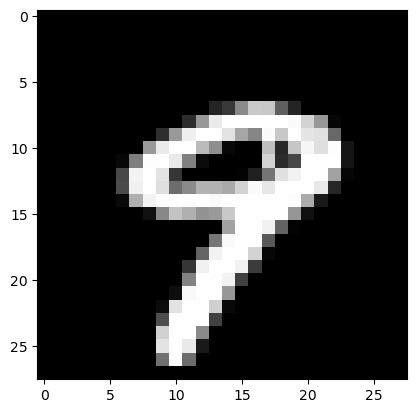

In [8]:
test_example = 9
p = model.predict(X_test_flat[test_example:test_example+1])

# Wyswietlenie wartości prognozy ("prawdopodobieństwa") p z przedziału [0,1]
print("Wartość prognozy dla wybranego przypadku: ", p)
print("Prawdziwa etykieta klasy dla wybranego przypadku: ", int(y_test_binary[test_example]))

# Użycie wartości progu w celu przypisania do odpowiednich klas 
predicted_class = 0 if p < 0.5 else 1
print("Przewidywana etykieta klasy dla wybranego przypadku: ", predicted_class)

plt.imshow(X_test[test_example], cmap="gray")

# Zadania do wykonania

<p><b>Zadanie 1</b></p>
Przeprowadź eksperyment, przy którym będzie inne przyporządkowanie do klas i przedstaw uzyskane wyniki zgodnie z zaleceniami prowadzącego.

Przykładowe 10 oryginalnych etykiet testowych:  [7 2 1 0 4 1 4 9 5 9]
Przykładowe 10 nowych etykiet (parzyste=0, nieparzyste=1):  [1 0 1 0 0 1 0 1 1 1]

Rozpoczęcie treningu modelu... (może to zająć dłuższą chwilę)

Wynik ewaluacji nowego wytrenowanego modelu (Accuracy): 0.9013

--- Wybrany losowy przypadek testowy ---
Prawdziwa wieloklasowa etykieta:  7
Prawdziwa nowa binarna etykieta (1=nieparzyste, 0=parzyste):  1
Przewidziana klasa (predykcja):  1


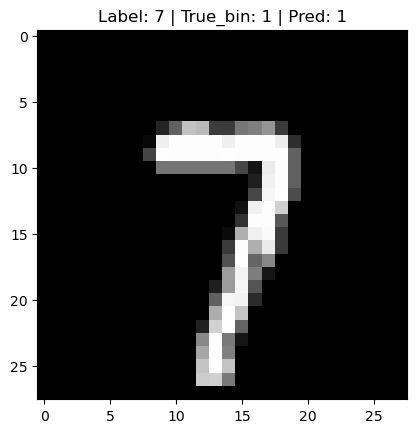

In [9]:
# Rozwiązanie Zadania 1 - Nowe przyporządkowanie do klas (Parzyste vs Nieparzyste)

# Problem binarny: 
# Klasa 0 - cyfry parzyste (0, 2, 4, 6, 8)
# Klasa 1 - cyfry nieparzyste (1, 3, 5, 7, 9)

# 1. Przygotowanie nowych etykiet
y_train_new_binary = np.where(y_train % 2 == 0, 0.0, 1.0).reshape(y_train.shape[0], 1).flatten()
y_test_new_binary = np.where(y_test % 2 == 0, 0.0, 1.0).reshape(y_test.shape[0], 1).flatten()

print("Przykładowe 10 oryginalnych etykiet testowych: ", y_test[:10])
print("Przykładowe 10 nowych etykiet (parzyste=0, nieparzyste=1): ", y_test_new_binary[:10].astype(int))

# 2. Trening modelu (korzystamy z już spłaszczonych danych X_train_flat i X_test_flat)
model_new = LogisticRegression(solver='newton-cg', random_state=42)
print("\nRozpoczęcie treningu modelu... (może to zająć dłuższą chwilę)")
model_new.fit(X_train_flat, y_train_new_binary)

# 3. Ewaluacja wytrenowanego modelu
score = model_new.score(X_test_flat, y_test_new_binary)
print("\nWynik ewaluacji nowego wytrenowanego modelu (Accuracy):", score)

# 4. Sprawdzenie na losowym przykładzie ze zbioru testowego
from random import randint
test_example = randint(0, X_test.shape[0] - 1)
p_new = model_new.predict(X_test_flat[test_example:test_example+1])

print("\n--- Wybrany losowy przypadek testowy ---")
print("Prawdziwa wieloklasowa etykieta: ", y_test[test_example])
print("Prawdziwa nowa binarna etykieta (1=nieparzyste, 0=parzyste): ", int(y_test_new_binary[test_example]))
print("Przewidziana klasa (predykcja): ", int(p_new[0]))

# Wyswietlenie cyfry
plt.imshow(X_test[test_example], cmap="gray")
plt.title(f"Label: {y_test[test_example]} | True_bin: {int(y_test_new_binary[test_example])} | Pred: {int(p_new[0])}")
plt.show()

![stopka.svg](stopka.svg)

### Wnioski na podstawie modyfikacji do Zadania 1

W ramach modyfikacji oryginalnego problemu przygotowałem nowe przyporządkowanie próbek do dwóch klas na zasadzie sprawdzania **parzystości cyfr**:
* **Klasa 0:** Cyfry parzyste (0, 2, 4, 6, 8)
* **Klasa 1:** Cyfry nieparzyste (1, 3, 5, 7, 9)

**Wyniki i Wnioski:**
1. **Zwiększona trudność problemu dla algorytmu:** 
W oryginalnym problemie (gdzie wyodrębnialiśmy tylko klasę dla kształtu określającego cyfrę `9`, a wszystkie inne były wrzucane do klasy `0`) skuteczność (*accuracy*) wynosiła bardzo wysokie **96.75%**. 
Po zmianie na dzielenie cyfr na parzyste i nieparzyste, dokładność (znów przy użyciu modelu *Logistic Regression*) bardzo gwałtownie spadła do poziomu około **90.1%**.
2. **Dlaczego tak się dzieje?** 
Przy klasyfikacji "9 vs reszta", model odnajdywał w nauczonych wagach jedynie piksele kluczowe dla "kółeczka i pionowej nóżki" dziesiątki. W naszym nowym układzie model stara się uśrednić w obszarze całego obrazka wagi w taki sposób, aby jednocześnie premiowały piksele pasujące do brzuszka 8, łabędziej szyi cyfry 2, koła zapisanego na początku zera i ostrych wcięć cyfry 4 - co jest gigantycznym wymieszaniem koncepcyjnym. Cechy przestały korelować się w spójny sposób liniowy.
3. Obserwacja losowych wyników, takich jak zaprezentowana w wynikach dla cyfry "7", pozwala jednak zauważyć, że regresja logistyczna dla wielkiego zbioru cech wejściowych (784 pikseli) wciąż wyciąga całkiem rewelacyjne $90\%$ trafień mimo wszystko, udowaniając użyteczność klasyfikatora dla baz danych i detekcji obrazu (tzw. "płytkich sieci").